downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Total number of images: 400
Total number of unique people: 40


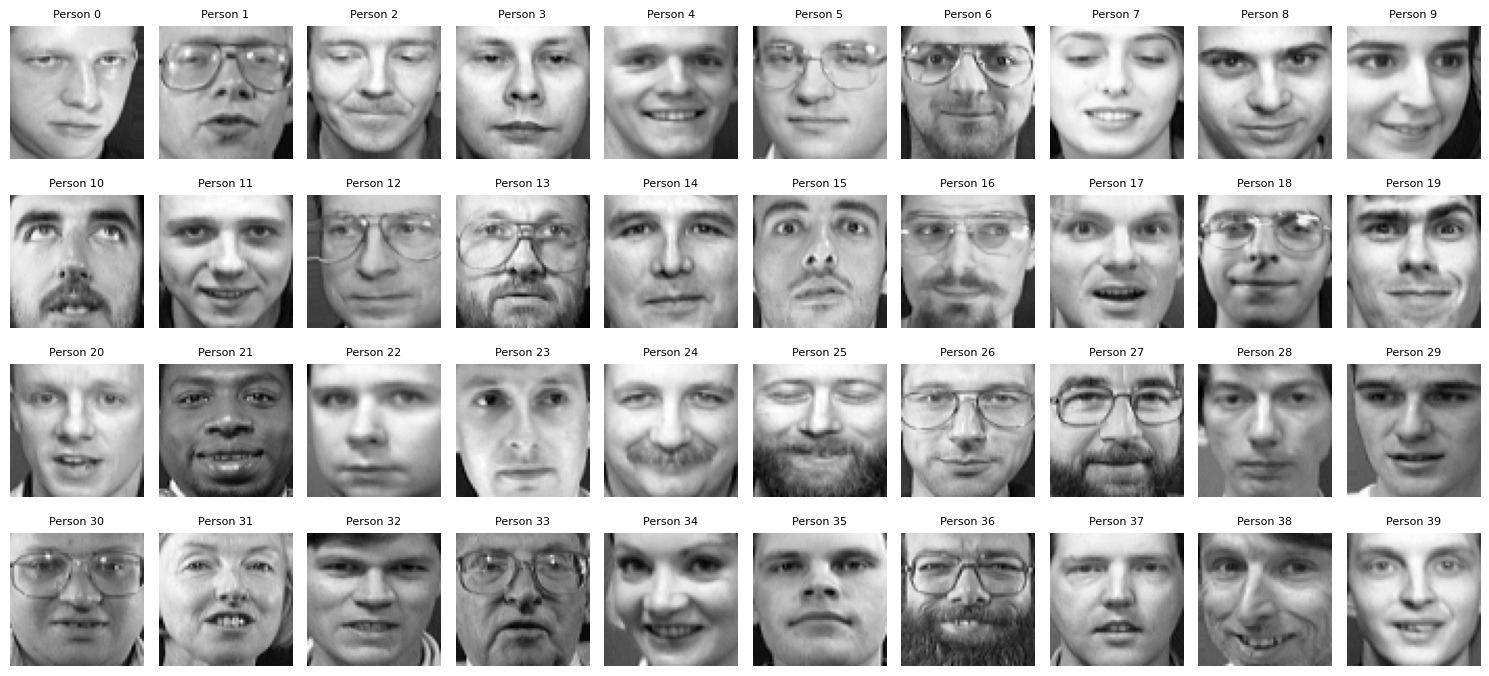

In [ ]:
# ----------------------------------------------------
# Title: Face Recognition Using SVM, Random Forest, and AdaBoost on the Olivetti Faces Dataset
# Author: Ehsan Saleh
# Course: Supervised Machine Learning
# Instructor: Dr. Ehsan Nazerfard
# Program: MCI AI Bootcamp (Generative AI with a Focus on Image Processing and Analysis)
# ----------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# 1. Load the dataset
faces_data = fetch_olivetti_faces(shuffle=True, random_state=42)
y = faces_data.target
images = faces_data.images

print(f"Total number of images: {len(images)}")
print(f"Total number of unique people: {len(np.unique(y))}")

# 2. Find the index of the first image for each of the 40 people
unique_ids = np.unique(y)
first_image_indices = []

for person_id in unique_ids:
    # Find the first index where the target matches the person_id
    idx = np.where(y == person_id)[0][0]
    first_image_indices.append(idx)

# 3. Display the images in a 4x10 grid layout
fig, axes = plt.subplots(4, 10, figsize=(15, 7))
axes = axes.ravel()

for i, idx in enumerate(first_image_indices):
    axes[i].imshow(images[idx], cmap='gray')
    axes[i].set_title(f"Person {y[idx]}", fontsize=8)
    axes[i].axis('off')  # Hide the axes for better visualization

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset
faces_data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces_data.data
y = faces_data.target

# 2. Split into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Initialize the models
models = {
    "SVM (Linear)": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

# 4. Train models and evaluate accuracy
results = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# 5. Display the comparison results
print("\n=== Model Comparison Results ===")
df_results = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
# Format accuracy as percentage
df_results['Accuracy'] = df_results['Accuracy'].map(lambda x: f"{x * 100:.2f}%")
print(df_results.to_string(index=False))


=== Model Comparison Results ===
        Model Accuracy
 SVM (Linear)   97.50%
Random Forest   95.00%
     AdaBoost   17.50%
